# FreeVIZ and SPCA comparison

In this notebook, we compare resulting vizualizations of FreeViz and SPCA for classification on four datasets.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import torch
import matplotlib.pyplot as plt
import numpy as np

import importlib
import utils
importlib.reload(utils)

from models import Freeviz
from models.spca_classification import SPCA_Classification
from utils import load_zoo_data, load_car_data, load_mushroom_data, load_glass_data, load_breast_cancer_data, scale_features, plot_projection

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# The ZOO dataset

#### Data preparation

In [3]:
E_raw, C, names, feature_names, class_names = load_zoo_data(device)
E = scale_features(E_raw)

#### Train FreeVIZ

In [4]:
freeviz = Freeviz(E.shape[1]).to(device)
freeviz.train(E, C)

P = freeviz(E)
A = freeviz.A
P_np = P.detach().cpu().numpy()
C_np = C.detach().cpu().numpy()
A_np = A.detach().cpu().numpy()

step: 1 loss: 18686.888671875
step: 2 loss: 18908.2890625
step: 3 loss: 20747.513671875
step: 4 loss: 19672.515625
step: 5 loss: 12327.8173828125
step: 6 loss: 11816.6328125
step: 7 loss: 11520.2734375
step: 8 loss: 11745.88671875
step: 9 loss: 12014.47265625
step: 10 loss: 12151.3095703125
step: 11 loss: 12283.1416015625


#### Train SPCA Classification

In [5]:
model = SPCA_Classification(input_dim=E.shape[1], latent_dim=2, num_classes=len(class_names), lr=0.05).to(device)
E_centered = E - E.mean(dim=0)
lam = 0.01
steps = 1000
model.train(E_centered, C, lam=lam, steps=steps, classifier_epochs=50)

L = model.L.detach().clone()
L = L - L.mean(dim=0, keepdim=True)
loading_norms = torch.norm(L, dim=1)
L = L / loading_norms.max()

Z = E_centered @ L
z_max = torch.abs(Z).max()
Z = Z / z_max

Z_np = Z.cpu().numpy()
C_np_spca = C.cpu().numpy()
L_np = L.cpu().numpy()

Step 0: loss = 3.1425, classifier loss = 1.8441
Step 10: loss = 2.4838, classifier loss = 1.1811
Step 20: loss = 2.2181, classifier loss = 0.9129
Step 30: loss = 2.0934, classifier loss = 0.7871
Step 40: loss = 2.0180, classifier loss = 0.7109
Step 50: loss = 1.9638, classifier loss = 0.6559
Step 60: loss = 1.9209, classifier loss = 0.6123
Step 70: loss = 1.8850, classifier loss = 0.5758
Step 80: loss = 1.8542, classifier loss = 0.5444
Step 90: loss = 1.8271, classifier loss = 0.5169
Step 100: loss = 1.8029, classifier loss = 0.4924
Step 110: loss = 1.7810, classifier loss = 0.4700
Step 120: loss = 1.7607, classifier loss = 0.4487
Step 130: loss = 1.7413, classifier loss = 0.4272
Step 140: loss = 1.7229, classifier loss = 0.4061
Step 150: loss = 1.7056, classifier loss = 0.3850
Step 160: loss = 1.6896, classifier loss = 0.3646
Step 170: loss = 1.6749, classifier loss = 0.3456
Step 180: loss = 1.6614, classifier loss = 0.3281
Step 190: loss = 1.6491, classifier loss = 0.3121
Step 200: l

### Side-by-side comparison

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/usr/lib/python3/dist-packages/matplotlib/transforms.py:627: RuntimeWarning: invalid value encountered in scalar subtract
  deltaw = (sw * width - width) / 2.0
/usr/lib/python3/dist-packages/matplotlib/transforms.py:628: RuntimeWarning: invalid value encountered in scalar subtract
  deltah = (sh * height - height) / 2.0
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


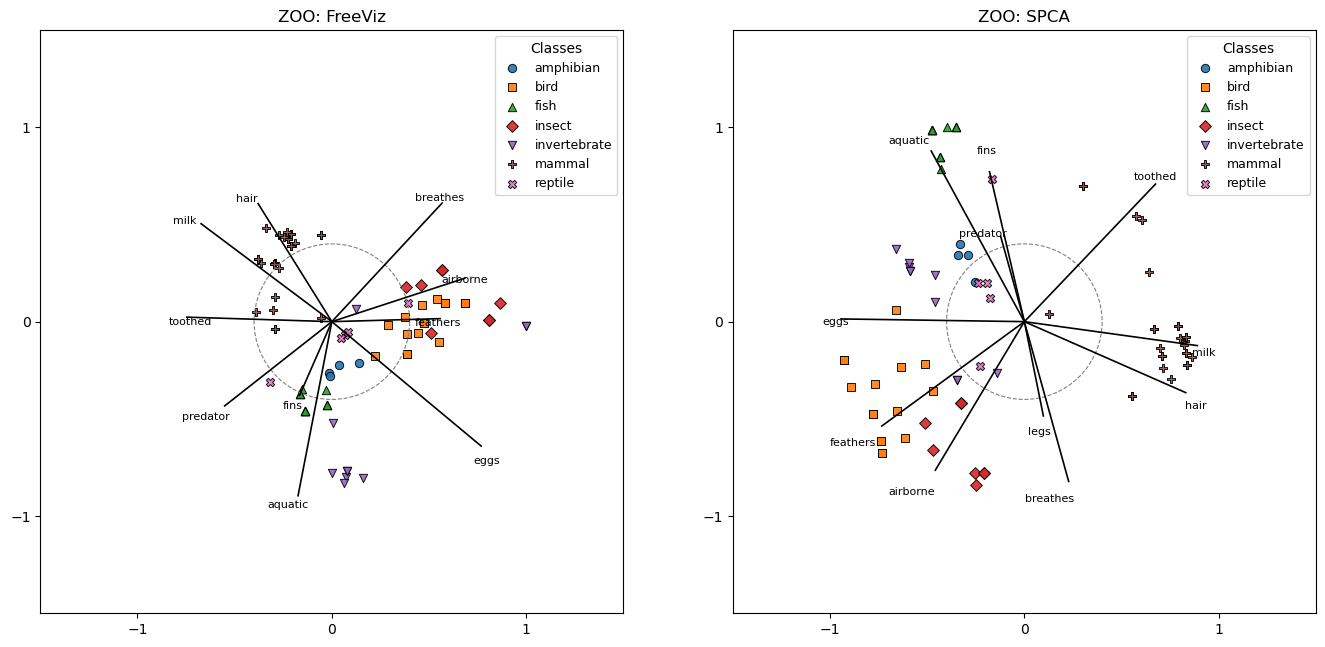

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    P_np, A_np, feature_names, C_np, class_names,
    title='ZOO: FreeViz', ax=ax1, text_scale=1.08, normalize_points=True
)

plot_projection(
    Z_np, L_np, feature_names, C_np_spca, class_names,
    title='ZOO: SPCA', ax=ax2, text_scale=1.1
)

plt.tight_layout()
plt.show()

# The MUSHROOM dataset

#### Data preparation

In [7]:
E_mush, C_mush, names_mush, feature_names_mush, class_names_mush = load_mushroom_data(device)
E_mush = scale_features(E_mush)

#### Train FreeVIZ

In [8]:
freeviz_mush = Freeviz(E_mush.shape[1]).to(device)
freeviz_mush.train(E_mush, C_mush)

P_mush = freeviz_mush(E_mush)
A_mush = freeviz_mush.A
P_mush_np = P_mush.detach().cpu().numpy()
C_mush_np = C_mush.detach().cpu().numpy()
A_mush_np = A_mush.detach().cpu().numpy()

step: 1 loss: 11156914.0
step: 2 loss: 2270743.25
step: 3 loss: 2286272.25
step: 4 loss: 2316779.0
step: 5 loss: 2224857.0
step: 6 loss: 2199510.5
step: 7 loss: 2204252.25
step: 8 loss: 2171202.75
step: 9 loss: 2179453.0
step: 10 loss: 2232810.5
step: 11 loss: 2246996.75


#### Train SPCA Classification

In [9]:
model_mush = SPCA_Classification(input_dim=E_mush.shape[1], latent_dim=2, num_classes=len(class_names_mush), lr=0.05).to(device)
E_mush_centered = E_mush - E_mush.mean(dim=0)
model_mush.train(E_mush_centered, C_mush, lam=0.01, steps=1000, classifier_epochs=50)

L_mush = model_mush.L.detach().clone()
L_mush = L_mush - L_mush.mean(dim=0, keepdim=True)
loading_norms_mush = torch.norm(L_mush, dim=1)
L_mush = L_mush / loading_norms_mush.max()

Z_mush = E_mush_centered @ L_mush
z_max_mush = torch.abs(Z_mush).max()
Z_mush = Z_mush / z_max_mush

Z_mush_np = Z_mush.cpu().numpy()
C_mush_np_spca = C_mush.cpu().numpy()
L_mush_np = L_mush.cpu().numpy()

Step 0: loss = 77.6911, classifier loss = 0.6322
Step 10: loss = 77.4365, classifier loss = 0.3765
Step 20: loss = 77.3734, classifier loss = 0.3127
Step 30: loss = 77.3546, classifier loss = 0.2936
Step 40: loss = 77.3532, classifier loss = 0.2922
Step 50: loss = 77.3523, classifier loss = 0.2911
Step 60: loss = 77.3514, classifier loss = 0.2902
Step 70: loss = 77.3506, classifier loss = 0.2894
Step 80: loss = 77.3500, classifier loss = 0.2887
Step 90: loss = 77.3494, classifier loss = 0.2881
Step 100: loss = 77.3489, classifier loss = 0.2875
Step 110: loss = 77.3484, classifier loss = 0.2871
Step 120: loss = 77.3480, classifier loss = 0.2866
Step 130: loss = 77.3477, classifier loss = 0.2862
Step 140: loss = 77.3474, classifier loss = 0.2859
Step 150: loss = 77.3471, classifier loss = 0.2856
Step 160: loss = 77.3469, classifier loss = 0.2853
Step 170: loss = 77.3467, classifier loss = 0.2851
Step 180: loss = 77.3465, classifier loss = 0.2849
Step 190: loss = 77.3463, classifier loss 

### Side-by-side comparison

/usr/lib/python3/dist-packages/matplotlib/transforms.py:627: RuntimeWarning: invalid value encountered in scalar subtract
  deltaw = (sw * width - width) / 2.0
/usr/lib/python3/dist-packages/matplotlib/transforms.py:628: RuntimeWarning: invalid value encountered in scalar subtract
  deltah = (sh * height - height) / 2.0


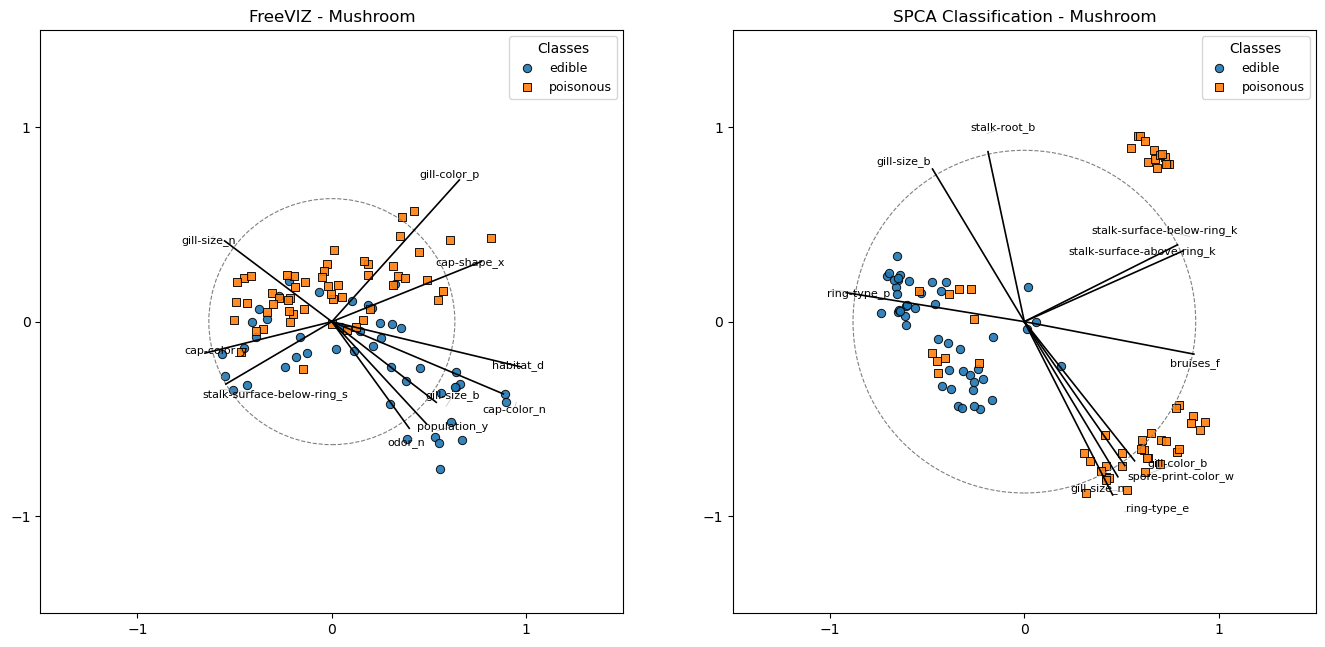

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    points=P_mush_np, vectors=A_mush_np, feature_names=feature_names_mush,
    class_codes=C_mush_np, class_names=class_names_mush,
    title='FreeVIZ - Mushroom', ax=ax1, text_scale=1.08, top_n_loadings=10, normalize_points=True
)

plot_projection(
    points=Z_mush_np, vectors=L_mush_np, feature_names=feature_names_mush,
    class_codes=C_mush_np_spca, class_names=class_names_mush,
    title='SPCA Classification - Mushroom', ax=ax2, text_scale=1.1, top_n_loadings=10
)

plt.tight_layout()
plt.show()

# The BREAST CANCER dataset

#### Data preparation

In [15]:
E_bc, C_bc, names_bc, feature_names_bc, class_names_bc = load_breast_cancer_data(device)
E_bc = scale_features(E_bc)

#### Train FreeVIZ

In [16]:
freeviz_bc = Freeviz(E_bc.shape[1]).to(device)
freeviz_bc.train(E_bc, C_bc)

P_bc = freeviz_bc(E_bc)
A_bc = freeviz_bc.A
P_bc_np = P_bc.detach().cpu().numpy()
C_bc_np = C_bc.detach().cpu().numpy()
A_bc_np = A_bc.detach().cpu().numpy()

step: 1 loss: 716257.75
step: 2 loss: 1011283.625
step: 3 loss: 869568.6875
step: 4 loss: 777568.1875
step: 5 loss: 810459.25
step: 6 loss: 680719.25
step: 7 loss: 696306.125
step: 8 loss: 705954.875
step: 9 loss: 671872.9375
step: 10 loss: 696420.3125
step: 11 loss: 1880516.625


#### Train SPCA Classification

In [17]:
model_bc = SPCA_Classification(input_dim=E_bc.shape[1], latent_dim=2, num_classes=len(class_names_bc), lr=0.05).to(device)
E_bc_centered = E_bc - E_bc.mean(dim=0)
model_bc.train(E_bc_centered, C_bc, lam=0.01, steps=1000, classifier_epochs=50)

L_bc = model_bc.L.detach().clone()
L_bc = L_bc - L_bc.mean(dim=0, keepdim=True)
loading_norms_bc = torch.norm(L_bc, dim=1)
L_bc = L_bc / loading_norms_bc.max()

Z_bc = E_bc_centered @ L_bc
z_max_bc = torch.abs(Z_bc).max()
Z_bc = Z_bc / z_max_bc

Z_bc_np = Z_bc.cpu().numpy()
C_bc_np_spca = C_bc.cpu().numpy()
L_bc_np = L_bc.cpu().numpy()

Step 0: loss = 0.9085, classifier loss = 0.6661
Step 10: loss = 0.7615, classifier loss = 0.5187
Step 20: loss = 0.6787, classifier loss = 0.4358
Step 30: loss = 0.6205, classifier loss = 0.3775
Step 40: loss = 0.5777, classifier loss = 0.3347
Step 50: loss = 0.5451, classifier loss = 0.3019
Step 60: loss = 0.5195, classifier loss = 0.2762
Step 70: loss = 0.4990, classifier loss = 0.2557
Step 80: loss = 0.4824, classifier loss = 0.2390
Step 90: loss = 0.4687, classifier loss = 0.2252
Step 100: loss = 0.4575, classifier loss = 0.2139
Step 110: loss = 0.4550, classifier loss = 0.2114
Step 120: loss = 0.4538, classifier loss = 0.2102
Step 130: loss = 0.4527, classifier loss = 0.2091
Step 140: loss = 0.4516, classifier loss = 0.2079
Step 150: loss = 0.4505, classifier loss = 0.2068
Step 160: loss = 0.4494, classifier loss = 0.2058
Step 170: loss = 0.4484, classifier loss = 0.2047
Step 180: loss = 0.4474, classifier loss = 0.2037
Step 190: loss = 0.4464, classifier loss = 0.2027
Step 200: l

### Side-by-side comparison

/usr/lib/python3/dist-packages/matplotlib/transforms.py:627: RuntimeWarning: invalid value encountered in scalar subtract
  deltaw = (sw * width - width) / 2.0
/usr/lib/python3/dist-packages/matplotlib/transforms.py:628: RuntimeWarning: invalid value encountered in scalar subtract
  deltah = (sh * height - height) / 2.0


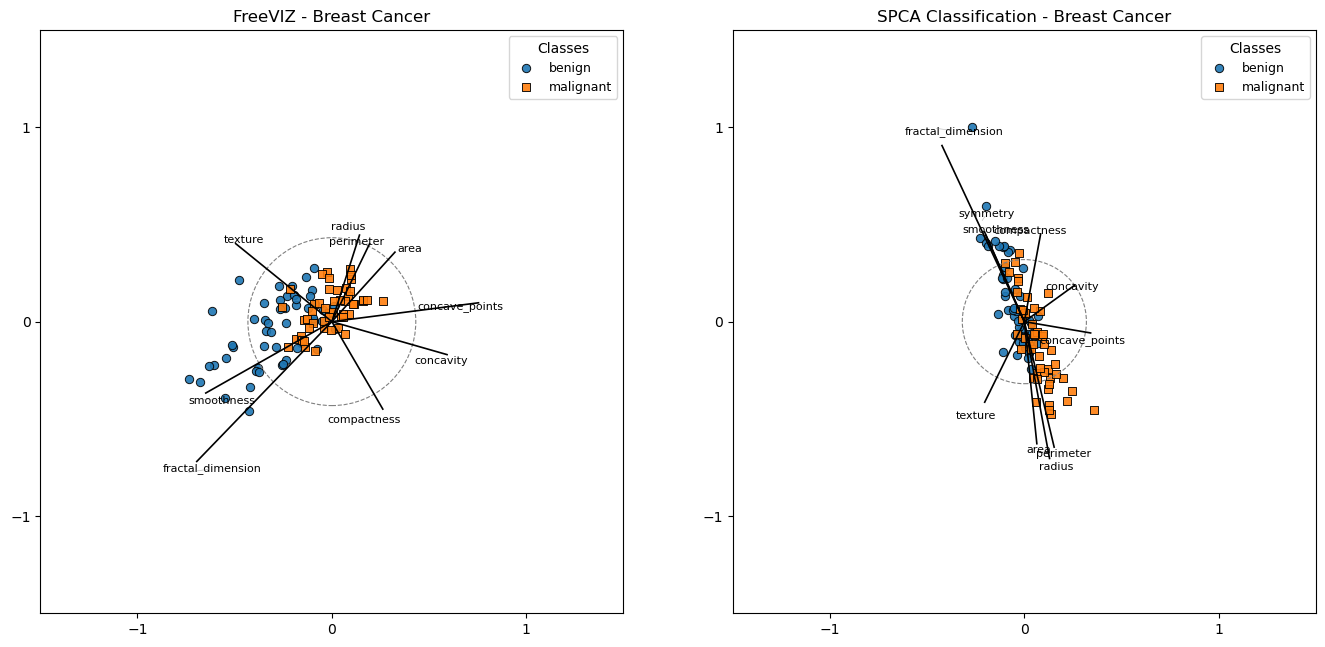

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    points=P_bc_np, vectors=A_bc_np, feature_names=feature_names_bc,
    class_codes=C_bc_np, class_names=class_names_bc,
    title='FreeVIZ - Breast Cancer', ax=ax1, text_scale=1.08, top_n_loadings=10, normalize_points=True
)

plot_projection(
    points=Z_bc_np, vectors=L_bc_np, feature_names=feature_names_bc,
    class_codes=C_bc_np_spca, class_names=class_names_bc,
    title='SPCA Classification - Breast Cancer', ax=ax2, text_scale=1.1, top_n_loadings=10
)

plt.tight_layout()
plt.show()